In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score

In [2]:
data = pd.read_csv(r'C:\Users\mohamed\Downloads\تدريب\diabetes.csv')

In [4]:
for col in cols:
    data[col] = data[col].replace(0, np.nan)
    data[col] = data[col].fillna(data[col].median())

In [5]:
x = data.drop('Outcome', axis=1)
y = data['Outcome']

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [8]:
model1 = LogisticRegression(class_weight='balanced')
model2 = SVC()
model3 = RandomForestClassifier()
model4 = GradientBoostingClassifier(n_estimators=1000)

In [9]:
def cal(model):
    model.fit(x_train, y_train)
    pre = model.predict(x_test)

    accuracy = accuracy_score(y_test, pre)
    recall = recall_score(y_test, pre)
    f1 = f1_score(y_test, pre)

    print(model)
    print("accuracy:", accuracy)
    print("recall:", recall)
    print("f1:", f1)

    cm = confusion_matrix(y_test, pre)

    df_cm = pd.DataFrame(cm,
                         index=["Actual 0", "Actual 1"],
                         columns=["Pred 0", "Pred 1"])

    print(df_cm)

    sns.heatmap(cm, annot=True)
    plt.show()

LogisticRegression(class_weight='balanced')
accuracy: 0.7012987012987013
recall: 0.7090909090909091
f1: 0.6290322580645161
          Pred 0  Pred 1
Actual 0      69      30
Actual 1      16      39


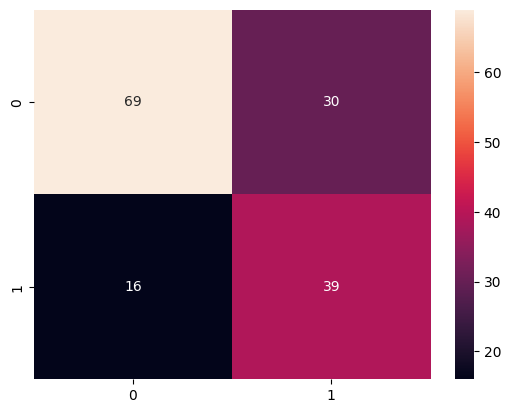

In [11]:
cal(model1)


In [12]:
probs = model1.predict_proba(x_test)[:,1]
y_pred = (probs > 0.3).astype(int)

LogisticRegression(class_weight='balanced')
accuracy: 0.7012987012987013
recall: 0.7090909090909091
f1: 0.6290322580645161
          Pred 0  Pred 1
Actual 0      69      30
Actual 1      16      39


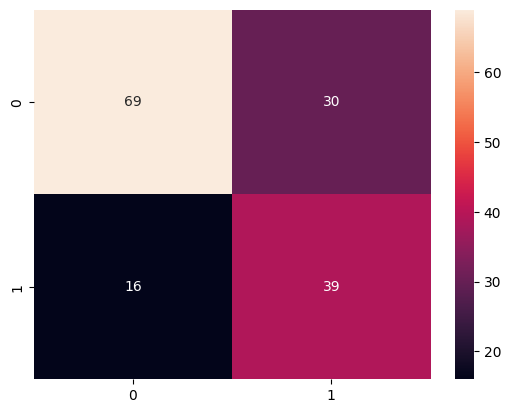

In [13]:
cal(model1)

RandomForestClassifier()
accuracy: 0.7402597402597403
recall: 0.6909090909090909
f1: 0.6551724137931034
          Pred 0  Pred 1
Actual 0      76      23
Actual 1      17      38


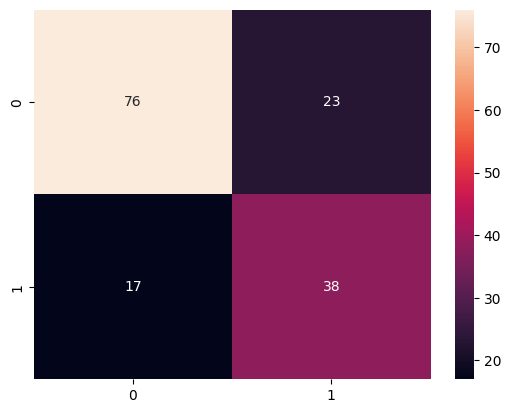

In [15]:
cal(model3)

SVC()
accuracy: 0.7467532467532467
recall: 0.5818181818181818
f1: 0.6213592233009708
          Pred 0  Pred 1
Actual 0      83      16
Actual 1      23      32


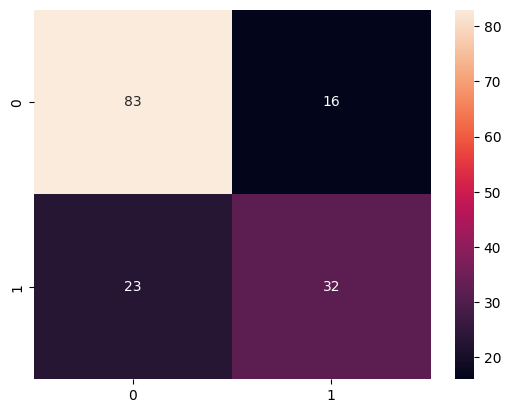

In [16]:
cal(model2)

In [19]:


new_patient = pd.DataFrame([[
    2,120,70,25,80,30.5,0.5,35
]], columns=x.columns)

new_patient = scaler.transform(new_patient)

In [21]:
prediction = model1.predict(new_patient)
print(prediction)

[0]


In [22]:
proba = model1.predict_proba(new_patient)
print(proba)

[[0.61142893 0.38857107]]


In [23]:
if proba[0][1] > 0.7:
    print("High risk")
elif proba[0][1] > 0.3:
    print("Medium risk")
else:
    print("Low risk")

Medium risk


In [24]:
samples = x_test[:10]
preds = model1.predict(samples)

print(preds)
print(y_test[:10].values)

[0 0 0 0 1 1 0 1 1 1]
[0 0 0 0 0 0 0 0 0 0]


In [28]:
from sklearn.metrics import precision_score
y_pred = model1.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7012987012987013
Recall: 0.7090909090909091
Precision: 0.5652173913043478
F1: 0.6290322580645161

Confusion Matrix:
[[69 30]
 [16 39]]


In [29]:
probs = model1.predict_proba(x_test)[:,1]
y_pred_new = (probs > 0.4).astype(int)

print(confusion_matrix(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("Precision:", precision_score(y_test, y_pred_new))

[[61 38]
 [11 44]]
Recall: 0.8
Precision: 0.5365853658536586
